# Generalizable Bangla Misinformation Detection

**Research objective:** evaluate whether Bangla misinformation classifiers generalize beyond ordinary random train/test splits to:

1. **Unseen topics**
2. **Unseen publishers / source groups**
3. **Future time periods**
4. **A different dataset**
5. **Noisy / perturbed Bangla text**

The notebook is designed for **Kaggle GPU** or **Google Colab GPU**.

## Primary dataset
**BanglaFakeNews2025** (4,000 manually annotated Bangla news articles; 2,000 Real + 2,000 Fake) is used as the main benchmark because it includes **Domain, Date, Category, Headline, Content, Label, Relation and fake-news type metadata**.

## External dataset
**BanFakeNews-2.0** (~60,000 Bangla articles; ~47K authentic + ~13K fake) is used for external / cross-dataset testing.

### Important
- `Label = 1` means **Real / Authentic**
- `Label = 0` means **Fake / Misinformation**
- Do **not** report results until you inspect the dataset diagnostics produced by this notebook.
- This notebook saves paper-ready CSVs and figures to `results/`.

## Dataset configuration used in this revised notebook

### Primary dataset — exact attached Kaggle files
- `Bangla_Fake_News_Dataset.xlsx` → `Label = 0` (Fake)
- `Bangla_Real_News_Dataset.xlsx` → `Label = 1` (Real)

### External dataset — exact attached BanFakeNews-2.0 files
- `train_cleaned.csv`
- `val_cleaned.csv`
- `test_cleaned.csv`

The downloaded BanFakeNews-2.0 files use four original labels.  
For the binary cross-dataset experiment this notebook preserves `Original_Label` and maps:

- `0, 1, 2 → 0 (Fake)`
- `3 → 1 (Real / Authentic)`

The external-transfer experiment uses the **official `test_cleaned.csv` split only**.


## 1. Environment setup

### Kaggle
Turn on **GPU** and **Internet** in Notebook Settings.

### Colab
Choose **Runtime → Change runtime type → T4 GPU**.

The installation below intentionally keeps `transformers` below v5 for compatibility.

In [1]:
!pip -q install -U "transformers>=4.45,<5" "accelerate>=0.34" "sentencepiece>=0.2" \
    "scikit-learn>=1.4" "pandas>=2.0" "matplotlib>=3.8" "scipy>=1.11" \
    "kagglehub>=0.3" "openpyxl>=3.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 573.1 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6

### Optional BanglaBERT normalizer

BanglaBERT was pretrained with the BUET CSE NLP normalization pipeline.  
The notebook attempts to install it; if installation fails, the pipeline still runs with conservative Unicode/text normalization.

In [2]:
import subprocess, sys
try:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/csebuetnlp/normalizer"],
        check=True
    )
    print("BanglaBERT normalizer installed.")
except Exception as e:
    print("Normalizer install skipped/fell back to Unicode normalization:", e)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 3.6 MB/s eta 0:00:00
BanglaBERT normalizer installed.


## 2. Imports, reproducibility, and experiment configuration

In [3]:
import os, re, gc, json, math, random, hashlib, unicodedata, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

from scipy.stats import binomtest

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# -----------------------------
# CORE CONFIGURATION
# -----------------------------
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# If auto-detection fails, put exact file/folder paths here.
PRIMARY_PATH = "/kaggle/input/datasets/mtareqrahman/bangla-fake-news-2025"
SECONDARY_PATH = "/kaggle/input/datasets/mtareqrahman/banfakenews-2"

# Transformer settings
MAIN_MODEL = "csebuetnlp/banglabert"
FAST_SHIFT_MODEL = "csebuetnlp/banglabert_small"
COMPARISON_MODELS = [
    "csebuetnlp/banglabert",
    "xlm-roberta-base",
    "bert-base-multilingual-cased",
]

MAX_LENGTH = 256
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
PATIENCE = 2

# Computational switches.
# Start with QUICK_MODE=True to validate the pipeline.
QUICK_MODE = True

# Transformer comparison on ordinary in-domain split.
RUN_3_TRANSFORMERS = True

# Shift experiments:
RUN_TOPIC_SHIFT_BASELINE = True
RUN_SOURCE_SHIFT_BASELINE = True
RUN_TEMPORAL_SHIFT_BASELINE = True

# Deep-learning shift experiments are the expensive part.
# FAST_SHIFT_MODEL is only 13M parameters and is practical for all folds.
RUN_TOPIC_SHIFT_TRANSFORMER = True
RUN_SOURCE_SHIFT_TRANSFORMER = True
RUN_TEMPORAL_SHIFT_TRANSFORMER = True

# External dataset and robustness.
RUN_CROSS_DATASET = True
RUN_ROBUSTNESS = True

# To keep a first run practical, limit held-out groups.
# Set these to None for every eligible topic/source fold.
MAX_TOPIC_FOLDS = 6
MAX_SOURCE_FOLDS = 6

# Minimum held-out examples per class for topic/source evaluations.
MIN_PER_CLASS_HELDOUT = 20

if QUICK_MODE:
    EPOCHS = 1
    MAX_TOPIC_FOLDS = 2
    MAX_SOURCE_FOLDS = 2
    RUN_3_TRANSFORMERS = False

Device: cuda
GPU: Tesla T4


## 3. Dataset locations

### Recommended setup

**Primary — BanglaFakeNews2025**
1. Download Version 3 from Mendeley Data.
2. Extract the archive.
3. On Kaggle, create/add a private dataset containing the extracted files; on Colab upload/mount Drive.
4. The loader below searches for tabular files and identifies the Bangla files from their schema/content.

**Secondary — BanFakeNews-2.0**
- On Kaggle, add the public dataset `hrithikmajumdar/bangla-fake-news`, **or**
- Let the code try to download it using `kagglehub`, **or**
- Download/upload `All60Kdataset.csv` manually.

The code never mixes the external dataset into primary training unless an experiment explicitly says so.

In [4]:
def candidate_roots():
    roots = []
    if Path("/kaggle/input").exists():
        roots.append(Path("/kaggle/input"))
    if Path("/content").exists():
        roots.append(Path("/content"))
    roots.append(Path("."))
    return roots

TAB_EXTS = {".csv", ".xlsx", ".xls", ".parquet"}

def list_tabular_files(root):
    root = Path(root)
    if root.is_file() and root.suffix.lower() in TAB_EXTS:
        return [root]
    if not root.exists():
        return []
    return [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in TAB_EXTS]

all_local_files = []
for r in candidate_roots():
    all_local_files.extend(list_tabular_files(r))

# de-duplicate paths
all_local_files = list(dict.fromkeys(map(str, all_local_files)))
print(f"Found {len(all_local_files)} local tabular files.")
for p in all_local_files[:30]:
    print(" -", p)

Found 11 local tabular files.
 - /kaggle/input/datasets/mtareqrahman/banfakenews-2/val_cleaned.csv
 - /kaggle/input/datasets/mtareqrahman/banfakenews-2/train_cleaned.csv
 - /kaggle/input/datasets/mtareqrahman/banfakenews-2/test_cleaned.csv
 - /kaggle/input/datasets/mtareqrahman/bangla-fake-news-2025/Bangla_Fake_News_Dataset.xlsx
 - /kaggle/input/datasets/mtareqrahman/bangla-fake-news-2025/Bangla_Real_News_Dataset.xlsx
 - /kaggle/input/datasets/mtareqrahman/bangla-fake-news-2025/Translated_English_Fake_News_Dataset.xlsx
 - /kaggle/input/datasets/mtareqrahman/bangla-fake-news-2025/Translated_English_Real_News_Dataset.xlsx
 - /content/sample_data/mnist_train_small.csv
 - /content/sample_data/california_housing_train.csv
 - /content/sample_data/california_housing_test.csv
 - /content/sample_data/mnist_test.csv


In [5]:
def read_table(path, nrows=None):
    path = Path(path)
    ext = path.suffix.lower()
    if ext == ".csv":
        # Try common encodings.
        for enc in ("utf-8", "utf-8-sig", "cp1252", "latin1"):
            try:
                return pd.read_csv(path, nrows=nrows, encoding=enc, low_memory=False)
            except UnicodeDecodeError:
                continue
        return pd.read_csv(path, nrows=nrows, low_memory=False)
    if ext in {".xlsx", ".xls"}:
        return pd.read_excel(path, nrows=nrows)
    if ext == ".parquet":
        df = pd.read_parquet(path)
        return df.head(nrows) if nrows else df
    raise ValueError(path)

def norm_col(c):
    c = str(c).strip().lower()
    c = re.sub(r"[^a-z0-9]+", "_", c).strip("_")
    return c

def inspect_file(path):
    try:
        df = read_table(path, nrows=5)
        cols = [norm_col(c) for c in df.columns]
        return {
            "path": str(path),
            "rows_preview": len(df),
            "columns": cols,
        }
    except Exception as e:
        return {"path": str(path), "error": str(e)}

inspections = [inspect_file(p) for p in all_local_files]
for x in inspections[:20]:
    print(x)

{'path': '/kaggle/input/datasets/mtareqrahman/banfakenews-2/val_cleaned.csv', 'rows_preview': 5, 'columns': ['headline', 'content', 'label']}
{'path': '/kaggle/input/datasets/mtareqrahman/banfakenews-2/train_cleaned.csv', 'rows_preview': 5, 'columns': ['headline', 'content', 'label']}
{'path': '/kaggle/input/datasets/mtareqrahman/banfakenews-2/test_cleaned.csv', 'rows_preview': 5, 'columns': ['headline', 'content', 'label']}
{'path': '/kaggle/input/datasets/mtareqrahman/bangla-fake-news-2025/Bangla_Fake_News_Dataset.xlsx', 'rows_preview': 5, 'columns': ['article_id', 'domain', 'date', 'category', 'headline', 'content', 'label', 'source', 'relation', 'f_type']}
{'path': '/kaggle/input/datasets/mtareqrahman/bangla-fake-news-2025/Bangla_Real_News_Dataset.xlsx', 'rows_preview': 5, 'columns': ['article_id', 'domain', 'date', 'category', 'headline', 'content', 'label', 'source', 'relation', 'f_type']}
{'path': '/kaggle/input/datasets/mtareqrahman/bangla-fake-news-2025/Translated_English_Fake

### Automatic primary/secondary file discovery

In [6]:
PRIMARY_CORE = {"domain", "date", "category", "headline", "content", "label"}
PRIMARY_RICH = {"relation", "f_type"}

def score_primary(cols):
    s = len(PRIMARY_CORE.intersection(cols)) * 10
    s += len(PRIMARY_RICH.intersection(cols)) * 15
    return s

def score_secondary(path, cols):
    name = str(path).lower()
    s = 0
    if "all60k" in name or "60k" in name:
        s += 100
    if "banfake" in name or "bangla-fake-news" in name:
        s += 30
    s += len(PRIMARY_CORE.intersection(cols)) * 5
    return s

def discover_primary_files(explicit_path=None):
    if explicit_path:
        files = list_tabular_files(explicit_path)
        if not files:
            raise FileNotFoundError(f"No tabular files under PRIMARY_PATH={explicit_path}")
        return files

    scored = []
    for info in inspections:
        if "columns" not in info:
            continue
        score = score_primary(set(info["columns"]))
        if score > 0:
            scored.append((score, Path(info["path"])))
    scored.sort(reverse=True, key=lambda x: x[0])

    # Keep rich-metadata files. Prefer anything containing relation/f_type.
    rich = []
    for score, p in scored:
        cols = set(inspect_file(p).get("columns", []))
        if PRIMARY_RICH.intersection(cols):
            rich.append(p)
    if rich:
        return rich

    # Fallback: top-scoring files that are NOT obviously All60K BanFakeNews.
    fallback = [p for s, p in scored if "all60k" not in p.name.lower()]
    return fallback[:8]

def discover_secondary_file(explicit_path=None):
    if explicit_path:
        p = Path(explicit_path)
        files = list_tabular_files(p)
        if p.is_file():
            return p
        if files:
            # prefer All60K
            files.sort(key=lambda x: score_secondary(x, set(inspect_file(x).get("columns", []))), reverse=True)
            return files[0]
        raise FileNotFoundError(f"No tabular files under SECONDARY_PATH={explicit_path}")

    scored = []
    for info in inspections:
        if "columns" not in info:
            continue
        p = Path(info["path"])
        scored.append((score_secondary(p, set(info["columns"])), p))
    scored.sort(reverse=True, key=lambda x: x[0])
    if scored and scored[0][0] >= 50:
        return scored[0][1]
    return None

primary_files = discover_primary_files(PRIMARY_PATH)
secondary_file = discover_secondary_file(SECONDARY_PATH)

print("\nPrimary candidates:")
for p in primary_files:
    print(" -", p)
print("\nSecondary candidate:", secondary_file)


Primary candidates:
 - /kaggle/input/datasets/mtareqrahman/bangla-fake-news-2025/Bangla_Fake_News_Dataset.xlsx
 - /kaggle/input/datasets/mtareqrahman/bangla-fake-news-2025/Bangla_Real_News_Dataset.xlsx
 - /kaggle/input/datasets/mtareqrahman/bangla-fake-news-2025/Translated_English_Fake_News_Dataset.xlsx
 - /kaggle/input/datasets/mtareqrahman/bangla-fake-news-2025/Translated_English_Real_News_Dataset.xlsx

Secondary candidate: /kaggle/input/datasets/mtareqrahman/banfakenews-2/val_cleaned.csv


### Optional automatic BanFakeNews-2.0 download

If the secondary dataset was not already added to Kaggle/Colab, this cell tries the public Kaggle dataset.

In [7]:
if secondary_file is None:
    try:
        import kagglehub
        downloaded = Path(kagglehub.dataset_download("hrithikmajumdar/bangla-fake-news"))
        print("Downloaded BanFakeNews-2.0 to:", downloaded)
        sec_files = list_tabular_files(downloaded)
        sec_files.sort(
            key=lambda p: score_secondary(p, set(inspect_file(p).get("columns", []))),
            reverse=True
        )
        secondary_file = sec_files[0] if sec_files else None
    except Exception as e:
        print("Automatic secondary download failed:", e)

print("Secondary file:", secondary_file)

Secondary file: /kaggle/input/datasets/mtareqrahman/banfakenews-2/val_cleaned.csv


## 4. Robust schema normalization and Bangla text cleaning

In [8]:
COL_ALIASES = {
    "article_id": {"article_id", "articleid", "id", "article"},
    "domain": {"domain", "publisher", "publisher_domain", "website", "news_source"},
    "date": {"date", "published_date", "publication_date", "publish_date", "time"},
    "category": {"category", "topic", "news_category", "class_category"},
    "headline": {"headline", "title", "news_headline"},
    "content": {"content", "text", "article_content", "body", "news", "description"},
    "label": {"label", "target", "class", "fake", "is_fake", "authenticity"},
    "source": {"source", "verification_source", "fact_check_source"},
    "relation": {"relation", "headline_content_relation"},
    "f_type": {"f_type", "ftype", "fake_type", "misinformation_type"},
}

def canonicalize_columns(df):
    ren = {}
    normalized = {c: norm_col(c) for c in df.columns}
    for original, nc in normalized.items():
        for canon, aliases in COL_ALIASES.items():
            if nc in aliases:
                ren[original] = canon
                break
    return df.rename(columns=ren)

BN_START, BN_END = "\u0980", "\u09FF"

def bangla_ratio(text):
    s = str(text)
    if not s:
        return 0.0
    letters = sum(ch.isalpha() for ch in s)
    bn = sum(BN_START <= ch <= BN_END for ch in s)
    return bn / max(letters, 1)

try:
    from normalizer import normalize as buet_normalize
    HAS_BUET_NORMALIZER = True
except Exception:
    HAS_BUET_NORMALIZER = False

def clean_text(x, use_buet=False):
    if pd.isna(x):
        return ""
    s = unicodedata.normalize("NFKC", str(x))
    s = re.sub(r"https?://\S+|www\.\S+", " URL ", s)
    s = re.sub(r"\S+@\S+", " EMAIL ", s)
    s = re.sub(r"\s+", " ", s).strip()
    if use_buet and HAS_BUET_NORMALIZER:
        try:
            s = buet_normalize(s)
        except Exception:
            pass
    return s

def normalize_label(v):
    if pd.isna(v):
        return np.nan
    # Preserve numeric 0/1.
    if isinstance(v, (int, np.integer)):
        return int(v) if int(v) in (0, 1) else np.nan
    if isinstance(v, float) and v in (0.0, 1.0):
        return int(v)

    s = str(v).strip().lower()
    real = {"1", "real", "true", "authentic", "genuine", "reliable"}
    fake = {"0", "fake", "false", "misinformation", "fabricated"}
    if s in real:
        return 1
    if s in fake:
        return 0
    return np.nan

def build_model_text(df, use_buet=False):
    headline = df.get("headline", pd.Series("", index=df.index)).fillna("").astype(str)
    content = df.get("content", pd.Series("", index=df.index)).fillna("").astype(str)
    combined = headline.str.strip() + " [SEP] " + content.str.strip()
    return combined.map(lambda s: clean_text(s, use_buet=use_buet))

def text_hash(s):
    x = re.sub(r"\s+", " ", str(s).lower()).strip()
    return hashlib.sha1(x.encode("utf-8", errors="ignore")).hexdigest()

## 5. Load and validate BanglaFakeNews2025

In [9]:
PRIMARY_DIR = Path(
    "/kaggle/input/datasets/mtareqrahman/bangla-fake-news-2025"
)

PRIMARY_FAKE_FILE = PRIMARY_DIR / "Bangla_Fake_News_Dataset.xlsx"
PRIMARY_REAL_FILE = PRIMARY_DIR / "Bangla_Real_News_Dataset.xlsx"

def load_primary_exact():
    fake = pd.read_excel(PRIMARY_FAKE_FILE)
    real = pd.read_excel(PRIMARY_REAL_FILE)

    # Exact verified schema from your Kaggle files.
    expected = {
        "Article ID", "Domain", "Date", "Category",
        "Headline", "Content", "Label",
        "Source", "Relation", "F-Type"
    }

    for name, df in [("Fake", fake), ("Real", real)]:
        missing = expected - set(df.columns)
        if missing:
            raise RuntimeError(
                f"{name} primary file is missing columns: {sorted(missing)}"
            )

    # Verify label semantics rather than silently assuming them.
    if set(fake["Label"].dropna().unique()) != {0}:
        raise RuntimeError(
            "Bangla_Fake_News_Dataset.xlsx does not contain only Label=0."
        )
    if set(real["Label"].dropna().unique()) != {1}:
        raise RuntimeError(
            "Bangla_Real_News_Dataset.xlsx does not contain only Label=1."
        )

    df = pd.concat([fake, real], ignore_index=True)

    rename_map = {
        "Article ID": "article_id",
        "Domain": "domain",
        "Date": "date",
        "Category": "category",
        "Headline": "headline",
        "Content": "content",
        "Label": "label",
        "Source": "source",
        "Relation": "relation",
        "F-Type": "f_type",
    }
    df = df.rename(columns=rename_map)

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["year"] = df["date"].dt.year

    for c in ["domain", "category", "source", "relation", "f_type"]:
        df[c] = df[c].astype("string").str.strip()

    df["text"] = build_model_text(df, use_buet=False)
    df = df[df["text"].str.len() >= 20].copy()

    df["text_hash"] = df["text"].map(text_hash)
    before = len(df)
    df = df.drop_duplicates("text_hash").reset_index(drop=True)
    print("Exact duplicate primary texts removed:", before - len(df))

    return df

primary = load_primary_exact()

print("\nPrimary shape:", primary.shape)
print("\nLabel counts:")
print(primary["label"].value_counts().sort_index())
print("\nYears:")
print(primary["year"].value_counts(dropna=False).sort_index())
print("\nTop categories:")
print(primary["category"].value_counts().head(15))
print("\nTop domains:")
print(primary["domain"].value_counts().head(15))

Exact duplicate primary texts removed: 8

Primary shape: (3992, 13)

Label counts:
label
0    1998
1    1994
Name: count, dtype: int64

Years:
year
2021     569
2022     415
2023     557
2024    1305
2025    1145
2026       1
Name: count, dtype: int64

Top categories:
category
Politics         788
Miscellaneous    636
International    537
Sports           343
National         316
Crime            248
Entertainment    216
Finance          192
Lifestyle        192
Education        189
Technology       178
Editorial        155
Entertainmen       1
Internationa       1
Name: count, dtype: int64[pyarrow]

Top domains:
domain
Facebook Page          1430
Prothomalo              599
Earki.com               527
Samakal News            363
Ittefaq                 322
News 24                 181
Bangladesh Pratidin     156
Independent News        140
Jamuna TV               136
Independent news         88
Dhakatribune             17
BBC News                  9
Amar Sangbad              8
Somoy Ne

In [10]:
# Sanity checks: do not continue silently with a broken dataset.
assert set(primary["label"].unique()) <= {0, 1}
assert primary["label"].nunique() == 2, "Primary data must contain both Real and Fake classes."

if len(primary) < 3000:
    print("WARNING: fewer than 3,000 primary rows found. Verify that both Bangla real and fake files were loaded.")

label_counts = primary["label"].value_counts()
imbalance = label_counts.max() / label_counts.min()
print("Class imbalance ratio:", round(float(imbalance), 3))

# Dataset summary
summary = pd.DataFrame({
    "metric": [
        "rows", "fake_rows", "real_rows", "unique_domains",
        "unique_categories", "min_date", "max_date"
    ],
    "value": [
        len(primary),
        int((primary.label == 0).sum()),
        int((primary.label == 1).sum()),
        primary["domain"].nunique(dropna=True),
        primary["category"].nunique(dropna=True),
        str(primary["date"].min()),
        str(primary["date"].max()),
    ]
})
display(summary)
summary.to_csv(RESULTS_DIR / "dataset_summary.csv", index=False)

Class imbalance ratio: 1.002


,metric,value
0,rows,3992
1,fake_rows,1998
2,real_rows,1994
3,unique_domains,26
4,unique_categories,14
5,min_date,2021-01-01 05:58:00
6,max_date,2026-12-18 01:00:00


## 6. Exploratory analysis and paper-ready figures

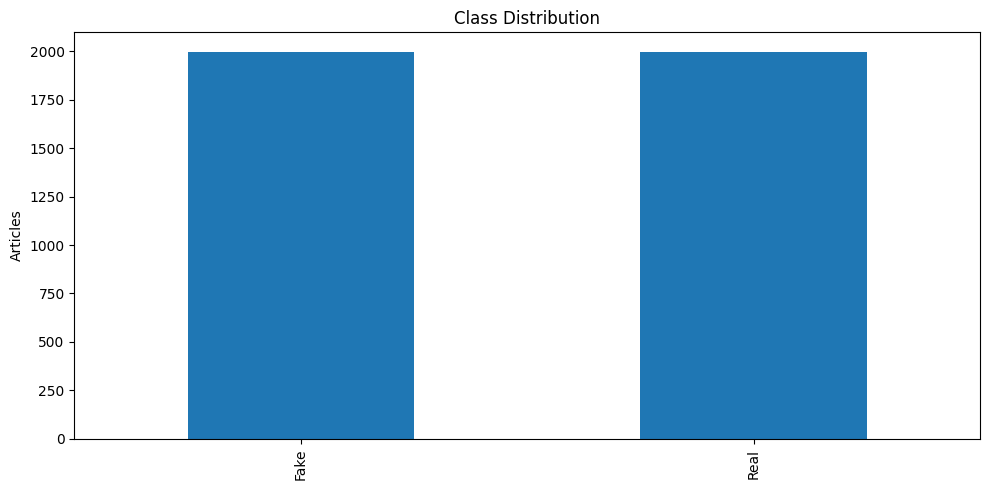

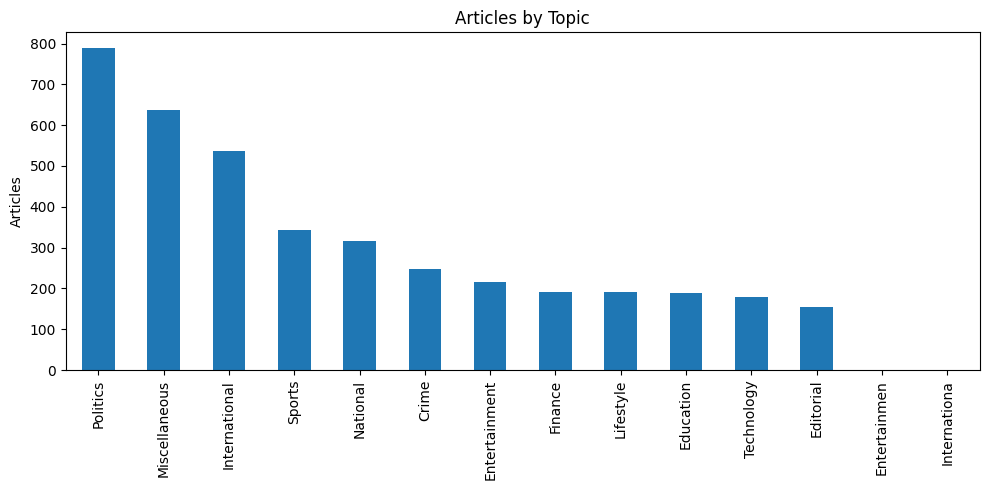

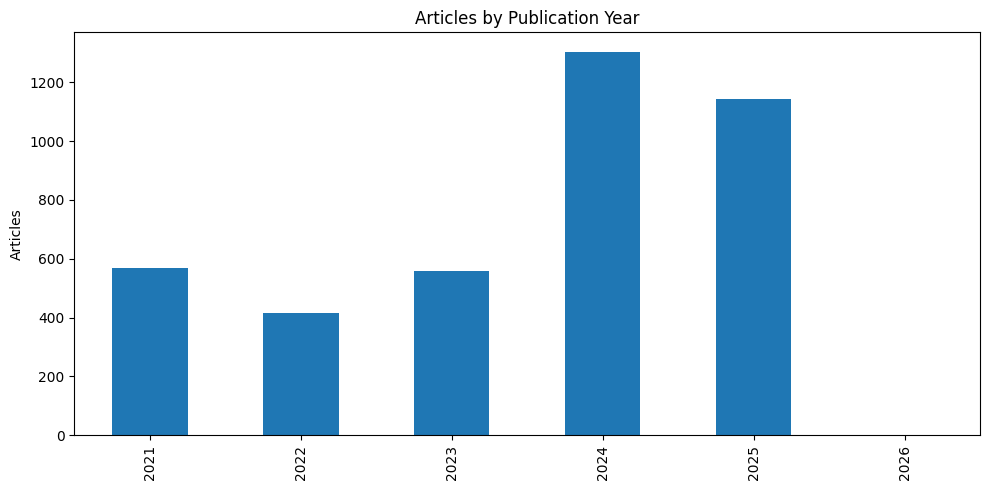

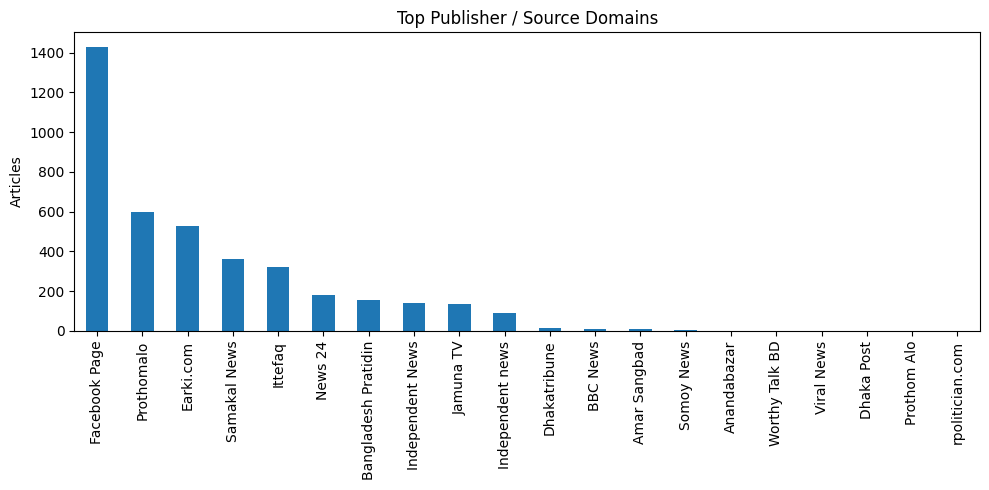

In [11]:
def save_bar(series, title, ylabel, filename, top_n=None):
    s = series.copy()
    if top_n is not None:
        s = s.head(top_n)
    fig, ax = plt.subplots(figsize=(10, 5))
    s.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / filename, dpi=250, bbox_inches="tight")
    plt.show()

save_bar(
    primary["label"].map({0: "Fake", 1: "Real"}).value_counts(),
    "Class Distribution", "Articles", "fig_class_distribution.png"
)

if primary["category"].notna().any():
    save_bar(
        primary["category"].value_counts(),
        "Articles by Topic", "Articles", "fig_topic_distribution.png", top_n=20
    )

if primary["year"].notna().any():
    save_bar(
        primary["year"].dropna().astype(int).value_counts().sort_index(),
        "Articles by Publication Year", "Articles", "fig_year_distribution.png"
    )

if primary["domain"].notna().any():
    save_bar(
        primary["domain"].value_counts().head(20),
        "Top Publisher / Source Domains", "Articles", "fig_domain_distribution.png"
    )

## 7. Evaluation helpers

Primary metric: **Macro-F1** because it weights both classes equally.

Also report:
- Accuracy
- Precision (macro)
- Recall (macro)
- F1 for Fake class
- F1 for Real class
- Confusion matrix

In [12]:
def metric_dict(y_true, y_pred, scores=None):
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0
    )
    out = {
        "n": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": p.mean(),
        "macro_recall": r.mean(),
        "macro_f1": f.mean(),
        "fake_f1": f[0],
        "real_f1": f[1],
    }
    if scores is not None:
        try:
            out["roc_auc"] = roc_auc_score(y_true, scores)
        except Exception:
            out["roc_auc"] = np.nan
    return out

def bootstrap_metric_ci(y_true, y_pred, metric="macro_f1", n_boot=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    vals = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt, yp = y_true[idx], y_pred[idx]
        # skip degenerate samples
        if len(np.unique(yt)) < 2:
            continue
        if metric == "macro_f1":
            vals.append(f1_score(yt, yp, average="macro"))
        elif metric == "accuracy":
            vals.append(accuracy_score(yt, yp))
    return np.quantile(vals, [0.025, 0.975]) if vals else (np.nan, np.nan)

def mcnemar_exact(y_true, pred_a, pred_b):
    y_true = np.asarray(y_true)
    a = np.asarray(pred_a) == y_true
    b = np.asarray(pred_b) == y_true
    n01 = int(np.sum(a & ~b))  # A correct, B wrong
    n10 = int(np.sum(~a & b))  # A wrong, B correct
    discordant = n01 + n10
    p = 1.0 if discordant == 0 else binomtest(min(n01, n10), discordant, 0.5).pvalue
    return {"a_correct_b_wrong": n01, "a_wrong_b_correct": n10, "p_value": p}

def display_confusion(y_true, y_pred, title="Confusion Matrix", save_name=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(cm)
    ax.set_xticks([0,1], ["Fake", "Real"])
    ax.set_yticks([0,1], ["Fake", "Real"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha="center", va="center")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    if save_name:
        fig.savefig(RESULTS_DIR / save_name, dpi=250, bbox_inches="tight")
    plt.show()

## 8. Leakage-aware ordinary in-domain split

In [13]:
def make_in_domain_split(df):
    # Exact duplicates were removed already.
    train_df, temp_df = train_test_split(
        df, test_size=0.30, stratify=df["label"], random_state=SEED
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

train_df, val_df, test_df = make_in_domain_split(primary)

print("Train:", len(train_df), train_df.label.value_counts().to_dict())
print("Val:  ", len(val_df), val_df.label.value_counts().to_dict())
print("Test: ", len(test_df), test_df.label.value_counts().to_dict())

assert set(train_df.text_hash).isdisjoint(test_df.text_hash)
assert set(val_df.text_hash).isdisjoint(test_df.text_hash)

Train: 2794 {0: 1398, 1: 1396}
Val:   599 {0: 300, 1: 299}
Test:  599 {0: 300, 1: 299}


## 9. Classical baselines

Two useful baselines:
1. **Word + character TF-IDF + Linear SVM**
2. **Word TF-IDF + Logistic Regression**

The word+character SVM is intentionally strong; weak baselines can exaggerate Transformer gains.

,n,accuracy,macro_precision,macro_recall,macro_f1,fake_f1,real_f1,roc_auc,model
0,599,0.96828,0.969132,0.968317,0.968268,0.967632,0.968903,0.990312,TFIDF_word+char_LinearSVM
1,599,0.93990,0.943717,0.939978,0.939777,0.937063,0.942492,0.987035,TFIDF_LogisticRegression


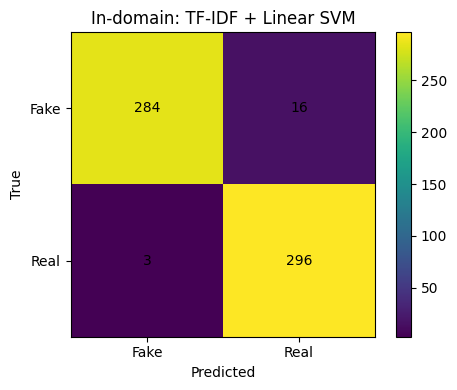

SVM macro-F1 95% bootstrap CI: [0.95325527 0.98160152]


In [14]:
def make_svm():
    features = FeatureUnion([
        ("word", TfidfVectorizer(
            analyzer="word", ngram_range=(1,2),
            min_df=2, max_df=0.98, sublinear_tf=True,
            max_features=150_000
        )),
        ("char", TfidfVectorizer(
            analyzer="char_wb", ngram_range=(3,5),
            min_df=2, sublinear_tf=True,
            max_features=150_000
        ))
    ])
    clf = LinearSVC(C=1.0, class_weight="balanced")
    from sklearn.pipeline import Pipeline
    return Pipeline([("features", features), ("clf", clf)])

def make_logreg():
    from sklearn.pipeline import Pipeline
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="word", ngram_range=(1,2),
            min_df=2, sublinear_tf=True, max_features=150_000
        )),
        ("clf", LogisticRegression(
            max_iter=3000, class_weight="balanced", C=2.0
        ))
    ])

def fit_eval_sklearn(model, tr, te, model_name):
    model.fit(tr["text"], tr["label"])
    pred = model.predict(te["text"])
    scores = None
    if hasattr(model, "decision_function"):
        scores = model.decision_function(te["text"])
    elif hasattr(model, "predict_proba"):
        scores = model.predict_proba(te["text"])[:,1]
    metrics = metric_dict(te["label"], pred, scores)
    metrics["model"] = model_name
    return model, pred, scores, metrics

baseline_rows = []
svm_model, svm_pred, svm_scores, svm_metrics = fit_eval_sklearn(
    make_svm(), train_df, test_df, "TFIDF_word+char_LinearSVM"
)
baseline_rows.append(svm_metrics)

lr_model, lr_pred, lr_scores, lr_metrics = fit_eval_sklearn(
    make_logreg(), train_df, test_df, "TFIDF_LogisticRegression"
)
baseline_rows.append(lr_metrics)

baseline_results = pd.DataFrame(baseline_rows).sort_values("macro_f1", ascending=False)
display(baseline_results)
baseline_results.to_csv(RESULTS_DIR / "standard_baseline_metrics.csv", index=False)

display_confusion(
    test_df.label, svm_pred,
    "In-domain: TF-IDF + Linear SVM",
    "fig_confusion_svm_indomain.png"
)

ci = bootstrap_metric_ci(test_df.label.values, svm_pred)
print("SVM macro-F1 95% bootstrap CI:", ci)

## 10. Transformer fine-tuning utilities

In [15]:
class TextDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=256, use_buet=False):
        self.texts = df["text"].astype(str).tolist()
        self.labels = df["label"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.use_buet = use_buet

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        if self.use_buet and HAS_BUET_NORMALIZER:
            text = clean_text(text, use_buet=True)
        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

@torch.no_grad()
def predict_transformer(model, loader):
    model.eval()
    ys, preds, probs = [], [], []
    for batch in loader:
        labels = batch.pop("labels").numpy()
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = model(**batch).logits
        pr = torch.softmax(logits, dim=1)[:,1].detach().cpu().numpy()
        pd_ = logits.argmax(dim=1).detach().cpu().numpy()
        ys.extend(labels.tolist())
        preds.extend(pd_.tolist())
        probs.extend(pr.tolist())
    return np.array(ys), np.array(preds), np.array(probs)

def train_transformer(
    train_data,
    val_data,
    model_name,
    run_name,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    batch_size=TRAIN_BATCH_SIZE,
    max_length=MAX_LENGTH,
    save_model=True
):
    print(f"\n=== {run_name}: {model_name} ===")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
        id2label={0:"FAKE", 1:"REAL"},
        label2id={"FAKE":0, "REAL":1}
    ).to(DEVICE)

    use_buet = "csebuetnlp/banglabert" in model_name.lower()

    train_ds = TextDataset(train_data, tokenizer, max_length, use_buet)
    val_ds = TextDataset(val_data, tokenizer, max_length, use_buet)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=torch.cuda.is_available()
    )
    val_loader = DataLoader(
        val_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=torch.cuda.is_available()
    )

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY
    )
    total_steps = max(1, len(train_loader) * epochs)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

    best_f1 = -1
    best_state = None
    history = []
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for batch in train_loader:
            labels = batch.pop("labels").to(DEVICE)
            batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                out = model(**batch, labels=labels)
                loss = out.loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            total_loss += float(loss.detach().cpu())

        yv, pv, probv = predict_transformer(model, val_loader)
        m = metric_dict(yv, pv, probv)
        m["epoch"] = epoch
        m["train_loss"] = total_loss / max(len(train_loader), 1)
        history.append(m)

        print(
            f"Epoch {epoch}/{epochs} | loss={m['train_loss']:.4f} "
            f"| val macro-F1={m['macro_f1']:.4f} "
            f"| val acc={m['accuracy']:.4f}"
        )

        if m["macro_f1"] > best_f1 + 1e-5:
            best_f1 = m["macro_f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print("Early stopping.")
                break

    model.load_state_dict(best_state)
    model.to(DEVICE)

    if save_model:
        model_dir = RESULTS_DIR / "models" / run_name
        model_dir.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(model_dir)
        tokenizer.save_pretrained(model_dir)

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(RESULTS_DIR / f"history_{run_name}.csv", index=False)

    return model, tokenizer, hist_df

def eval_transformer(model, tokenizer, df, model_name, max_length=MAX_LENGTH):
    use_buet = "csebuetnlp/banglabert" in model_name.lower()
    ds = TextDataset(df, tokenizer, max_length, use_buet)
    loader = DataLoader(
        ds, batch_size=EVAL_BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=torch.cuda.is_available()
    )
    y, pred, prob = predict_transformer(model, loader)
    return y, pred, prob, metric_dict(y, pred, prob)

def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 11. Standard Transformer comparison

Recommended paper comparison:
- BanglaBERT
- XLM-R base
- multilingual BERT

`QUICK_MODE=True` trains only the main model.


=== indomain_csebuetnlp__banglabert: csebuetnlp/banglabert ===


tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at csebuetnlp/banglabert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Epoch 1/1 | loss=0.1851 | val macro-F1=0.9800 | val acc=0.9800


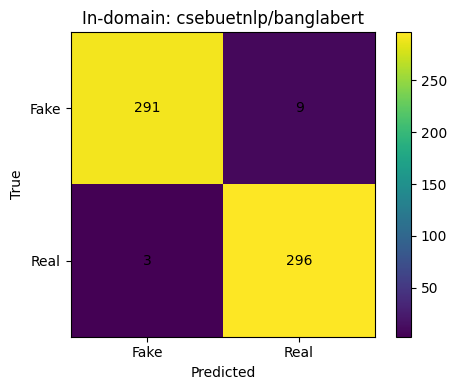

,n,accuracy,macro_precision,macro_recall,macro_f1,fake_f1,real_f1,roc_auc,model
0,599,0.979967,0.980144,0.979983,0.979965,0.979798,0.980132,0.992553,csebuetnlp/banglabert


Main Transformer macro-F1 95% bootstrap CI: [0.96823742 0.98997531]


In [16]:
standard_transformer_rows = []
standard_predictions = {}

models_to_run = COMPARISON_MODELS if RUN_3_TRANSFORMERS else [MAIN_MODEL]

for model_name in models_to_run:
    short = model_name.replace("/", "__")
    model, tok, hist = train_transformer(
        train_df, val_df,
        model_name=model_name,
        run_name=f"indomain_{short}"
    )
    y, pred, prob, met = eval_transformer(model, tok, test_df, model_name)
    met["model"] = model_name
    standard_transformer_rows.append(met)
    standard_predictions[model_name] = {
        "y": y, "pred": pred, "prob": prob
    }

    if model_name == MAIN_MODEL:
        display_confusion(
            y, pred,
            f"In-domain: {model_name}",
            "fig_confusion_banglabert_indomain.png"
        )
        main_indomain_model = model
        main_indomain_tokenizer = tok
        main_indomain_pred = pred
        main_indomain_prob = prob
    else:
        del model, tok
        clear_gpu()

standard_transformer_results = pd.DataFrame(standard_transformer_rows).sort_values(
    "macro_f1", ascending=False
)
display(standard_transformer_results)
standard_transformer_results.to_csv(
    RESULTS_DIR / "standard_transformer_metrics.csv", index=False
)

if MAIN_MODEL in standard_predictions:
    ci = bootstrap_metric_ci(
        standard_predictions[MAIN_MODEL]["y"],
        standard_predictions[MAIN_MODEL]["pred"]
    )
    print("Main Transformer macro-F1 95% bootstrap CI:", ci)

### Statistical paired comparison: SVM vs main Transformer

In [17]:
if MAIN_MODEL in standard_predictions:
    trans_pred = standard_predictions[MAIN_MODEL]["pred"]
    trans_y = standard_predictions[MAIN_MODEL]["y"]
    assert np.array_equal(trans_y, test_df.label.values)

    mc = mcnemar_exact(test_df.label.values, svm_pred, trans_pred)
    print("Exact McNemar comparison:")
    print(mc)

    pd.DataFrame([mc]).to_csv(
        RESULTS_DIR / "mcnemar_svm_vs_main_transformer.csv", index=False
    )

Exact McNemar comparison:
{'a_correct_b_wrong': 1, 'a_wrong_b_correct': 8, 'p_value': np.float64(0.0390625)}


# 12. Topic-shift generalization

For each eligible category:

**Train:** every other topic  
**Validation:** stratified subset of the training topics  
**Test:** the completely held-out topic

This tests whether high ordinary test accuracy survives a topical distribution shift.

In [18]:
def eligible_topics(df, min_per_class=MIN_PER_CLASS_HELDOUT):
    if not df["category"].notna().any():
        return []
    out = []
    for topic, g in df.dropna(subset=["category"]).groupby("category"):
        counts = g.label.value_counts()
        if all(counts.get(c, 0) >= min_per_class for c in [0,1]):
            out.append((topic, len(g)))
    out.sort(key=lambda x: x[1], reverse=True)
    return [x[0] for x in out]

topics = eligible_topics(primary)
if MAX_TOPIC_FOLDS is not None:
    topics = topics[:MAX_TOPIC_FOLDS]
print("Topic folds:", topics)

Topic folds: ['Politics', 'Miscellaneous']


In [19]:
topic_baseline_rows = []

if RUN_TOPIC_SHIFT_BASELINE:
    for topic in topics:
        te = primary[primary.category == topic].copy()
        pool = primary[primary.category != topic].copy()

        tr, va = train_test_split(
            pool, test_size=0.15, stratify=pool.label, random_state=SEED
        )

        _, pred, score, met = fit_eval_sklearn(
            make_svm(), tr, te, f"SVM_topic_{topic}"
        )
        met.update({
            "heldout_topic": topic,
            "train_n": len(tr),
            "test_n": len(te),
        })
        topic_baseline_rows.append(met)
        print(topic, "macro-F1 =", round(met["macro_f1"], 4))

topic_baseline = pd.DataFrame(topic_baseline_rows)
display(topic_baseline)
topic_baseline.to_csv(RESULTS_DIR / "topic_shift_baseline.csv", index=False)

Politics macro-F1 = 0.9604
Miscellaneous macro-F1 = 0.9444


,n,accuracy,macro_precision,macro_recall,macro_f1,fake_f1,real_f1,roc_auc,model,heldout_topic,train_n,test_n
0,788,0.965736,0.955240,0.966143,0.960411,0.974930,0.945892,0.997559,SVM_topic_Politics,Politics,2723,788
1,636,0.946541,0.938595,0.953664,0.944357,0.955381,0.933333,0.985715,SVM_topic_Miscellaneous,Miscellaneous,2852,636


In [20]:
topic_transformer_rows = []

if RUN_TOPIC_SHIFT_TRANSFORMER:
    for topic in topics:
        clear_gpu()
        te = primary[primary.category == topic].copy()
        pool = primary[primary.category != topic].copy()
        tr, va = train_test_split(
            pool, test_size=0.15, stratify=pool.label, random_state=SEED
        )

        run = "topic_" + re.sub(r"[^a-zA-Z0-9]+", "_", str(topic))[:40]
        model, tok, _ = train_transformer(
            tr, va,
            model_name=FAST_SHIFT_MODEL,
            run_name=run,
            epochs=max(1, EPOCHS-1),
            save_model=False
        )
        y, pred, prob, met = eval_transformer(
            model, tok, te, FAST_SHIFT_MODEL
        )
        met.update({
            "heldout_topic": topic,
            "model": FAST_SHIFT_MODEL,
            "train_n": len(tr),
            "test_n": len(te),
        })
        topic_transformer_rows.append(met)
        print(topic, "macro-F1 =", round(met["macro_f1"], 4))
        del model, tok
        clear_gpu()

topic_transformer = pd.DataFrame(topic_transformer_rows)
display(topic_transformer)
topic_transformer.to_csv(RESULTS_DIR / "topic_shift_transformer.csv", index=False)


=== topic_Politics: csebuetnlp/banglabert_small ===


tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/55.0M [00:00<?, ?B/s]

Epoch 1/1 | loss=0.5069 | val macro-F1=0.9599 | val acc=0.9605
Politics macro-F1 = 0.9708

=== topic_Miscellaneous: csebuetnlp/banglabert_small ===


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at csebuetnlp/banglabert_small and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/1 | loss=0.5021 | val macro-F1=0.9541 | val acc=0.9544
Miscellaneous macro-F1 = 0.9237


,n,accuracy,macro_precision,macro_recall,macro_f1,fake_f1,real_f1,roc_auc,heldout_topic,model,train_n,test_n
0,788,0.974619,0.964224,0.978227,0.970769,0.981378,0.960159,0.997152,Politics,csebuetnlp/banglabert_small,2723,788
1,636,0.926101,0.917854,0.937167,0.923692,0.937250,0.910134,0.974210,Miscellaneous,csebuetnlp/banglabert_small,2852,636


# 13. Publisher/source shift

A subtle problem with this dataset is that some domains may contain almost exclusively one label.  
A naïve leave-one-domain-out test can therefore become a one-class test.

To avoid that, this notebook builds **paired held-out source folds**:
- one major Fake-associated domain
- one major Real-associated domain

The held-out test therefore retains both classes while containing publisher domains never seen in training.

In [21]:
def source_label_profile(df):
    g = (
        df.dropna(subset=["domain"])
          .groupby("domain")["label"]
          .agg(["count", "mean"])
          .sort_values("count", ascending=False)
    )
    # mean ~0 => fake-heavy; mean ~1 => real-heavy
    return g

source_profile = source_label_profile(primary)
display(source_profile.head(30))
source_profile.to_csv(RESULTS_DIR / "source_label_profile.csv")

,count,mean
domain,,
Facebook Page,1430,0.000000
Prothomalo,599,0.979967
Earki.com,527,0.000000
Samakal News,363,0.997245
Ittefaq,322,0.990683
News 24,181,0.983425
Bangladesh Pratidin,156,0.993590
Independent News,140,1.000000
Jamuna TV,136,0.977941


In [22]:
def build_source_pair_folds(df, min_count=MIN_PER_CLASS_HELDOUT, max_folds=MAX_SOURCE_FOLDS):
    prof = source_label_profile(df).copy()

    fake_domains = prof[(prof["mean"] <= 0.20) & (prof["count"] >= min_count)].index.tolist()
    real_domains = prof[(prof["mean"] >= 0.80) & (prof["count"] >= min_count)].index.tolist()

    # Pair high-volume domains from each class.
    n = min(len(fake_domains), len(real_domains))
    if max_folds is not None:
        n = min(n, max_folds)

    folds = []
    for i in range(n):
        folds.append((fake_domains[i], real_domains[i]))
    return folds

source_folds = build_source_pair_folds(primary)
print("Source-pair folds:")
for f in source_folds:
    print(" -", f)

Source-pair folds:
 - ('Facebook Page', 'Prothomalo')
 - ('Earki.com', 'Samakal News')


In [23]:
source_baseline_rows = []

if RUN_SOURCE_SHIFT_BASELINE:
    for fake_domain, real_domain in source_folds:
        held = {fake_domain, real_domain}
        te = primary[primary.domain.isin(held)].copy()
        pool = primary[~primary.domain.isin(held)].copy()

        if te.label.nunique() < 2 or min(te.label.value_counts().to_dict().get(0,0),
                                         te.label.value_counts().to_dict().get(1,0)) < 5:
            print("Skipping insufficient pair:", held)
            continue

        tr, va = train_test_split(
            pool, test_size=0.15, stratify=pool.label, random_state=SEED
        )

        _, pred, score, met = fit_eval_sklearn(
            make_svm(), tr, te, "SVM_source_shift"
        )
        met.update({
            "heldout_fake_domain": fake_domain,
            "heldout_real_domain": real_domain,
            "train_n": len(tr),
            "test_n": len(te),
        })
        source_baseline_rows.append(met)
        print(held, "macro-F1 =", round(met["macro_f1"], 4))

source_baseline = pd.DataFrame(source_baseline_rows)
display(source_baseline)
source_baseline.to_csv(RESULTS_DIR / "source_shift_baseline.csv", index=False)

{'Prothomalo', 'Facebook Page'} macro-F1 = 0.2848
{'Earki.com', 'Samakal News'} macro-F1 = 0.3283


,n,accuracy,macro_precision,macro_recall,macro_f1,fake_f1,real_f1,roc_auc,model,heldout_fake_domain,heldout_real_domain,train_n,test_n
0,2029,0.327748,0.616486,0.524015,0.284838,0.109661,0.460016,0.870683,SVM_source_shift,Facebook Page,Prothomalo,1668,2029
1,890,0.428090,0.707807,0.517992,0.328328,0.069470,0.587186,0.871563,SVM_source_shift,Earki.com,Samakal News,2636,890


In [24]:
source_transformer_rows = []

if RUN_SOURCE_SHIFT_TRANSFORMER:
    for fold_i, (fake_domain, real_domain) in enumerate(source_folds, start=1):
        clear_gpu()
        held = {fake_domain, real_domain}
        te = primary[primary.domain.isin(held)].copy()
        pool = primary[~primary.domain.isin(held)].copy()

        if te.label.nunique() < 2:
            continue

        tr, va = train_test_split(
            pool, test_size=0.15, stratify=pool.label, random_state=SEED
        )

        model, tok, _ = train_transformer(
            tr, va,
            model_name=FAST_SHIFT_MODEL,
            run_name=f"source_pair_{fold_i}",
            epochs=max(1, EPOCHS-1),
            save_model=False
        )
        y, pred, prob, met = eval_transformer(model, tok, te, FAST_SHIFT_MODEL)
        met.update({
            "fold": fold_i,
            "heldout_fake_domain": fake_domain,
            "heldout_real_domain": real_domain,
            "model": FAST_SHIFT_MODEL,
            "train_n": len(tr),
            "test_n": len(te),
        })
        source_transformer_rows.append(met)
        print(held, "macro-F1 =", round(met["macro_f1"], 4))
        del model, tok
        clear_gpu()

source_transformer = pd.DataFrame(source_transformer_rows)
display(source_transformer)
source_transformer.to_csv(RESULTS_DIR / "source_shift_transformer.csv", index=False)


=== source_pair_1: csebuetnlp/banglabert_small ===


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at csebuetnlp/banglabert_small and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/1 | loss=0.5913 | val macro-F1=0.9250 | val acc=0.9424
{'Prothomalo', 'Facebook Page'} macro-F1 = 0.2579

=== source_pair_2: csebuetnlp/banglabert_small ===


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at csebuetnlp/banglabert_small and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/1 | loss=0.4884 | val macro-F1=0.9698 | val acc=0.9700
{'Earki.com', 'Samakal News'} macro-F1 = 0.308


,n,accuracy,macro_precision,macro_recall,macro_f1,fake_f1,real_f1,roc_auc,fold,heldout_fake_domain,heldout_real_domain,model,train_n,test_n
0,2029,0.310498,0.626302,0.513900,0.257937,0.060443,0.455430,0.823134,1,Facebook Page,Prothomalo,csebuetnlp/banglabert_small,1668,2029
1,890,0.416854,0.705448,0.508523,0.307991,0.033520,0.582462,0.909609,2,Earki.com,Samakal News,csebuetnlp/banglabert_small,2636,890


# 14. Temporal generalization

Preferred split when the dataset supports it:

- **Train:** 2021–2023
- **Validation:** 2024
- **Test:** 2025

This is much more realistic than randomly mixing years.

In [25]:
def make_temporal_split(df):
    d = df.dropna(subset=["year"]).copy()
    years = sorted(d.year.dropna().astype(int).unique())
    print("Available years:", years)

    if {2024, 2025}.issubset(set(years)):
        tr = d[d.year <= 2023].copy()
        va = d[d.year == 2024].copy()
        te = d[d.year == 2025].copy()
    elif len(years) >= 3:
        tr_years = years[:-2]
        va_year = years[-2]
        te_year = years[-1]
        tr = d[d.year.isin(tr_years)].copy()
        va = d[d.year == va_year].copy()
        te = d[d.year == te_year].copy()
    else:
        return None

    if min(len(tr), len(va), len(te)) == 0:
        return None
    if any(x.label.nunique() < 2 for x in [tr, va, te]):
        print("WARNING: at least one temporal partition does not contain both classes.")
    return tr, va, te

temporal = make_temporal_split(primary)
if temporal:
    temp_train, temp_val, temp_test = temporal
    print("Train years:", sorted(temp_train.year.unique()), len(temp_train), temp_train.label.value_counts().to_dict())
    print("Val years:", sorted(temp_val.year.unique()), len(temp_val), temp_val.label.value_counts().to_dict())
    print("Test years:", sorted(temp_test.year.unique()), len(temp_test), temp_test.label.value_counts().to_dict())

Available years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Train years: [np.int32(2021), np.int32(2022), np.int32(2023)] 1541 {1: 892, 0: 649}
Val years: [np.int32(2024)] 1305 {1: 760, 0: 545}
Test years: [np.int32(2025)] 1145 {0: 804, 1: 341}


In [26]:
temporal_rows = []

if RUN_TEMPORAL_SHIFT_BASELINE and temporal:
    _, pred, score, met = fit_eval_sklearn(
        make_svm(), temp_train, temp_test, "SVM_temporal"
    )
    met.update({
        "model": "TFIDF_word+char_LinearSVM",
        "train_year_max": int(temp_train.year.max()),
        "validation_year": int(temp_val.year.min()),
        "test_year": int(temp_test.year.min()),
    })
    temporal_rows.append(met)

if RUN_TEMPORAL_SHIFT_TRANSFORMER and temporal:
    clear_gpu()
    model, tok, _ = train_transformer(
        temp_train, temp_val,
        model_name=MAIN_MODEL,
        run_name="temporal_main_model",
        save_model=False
    )
    y, pred, prob, met = eval_transformer(model, tok, temp_test, MAIN_MODEL)
    met.update({
        "model": MAIN_MODEL,
        "train_year_max": int(temp_train.year.max()),
        "validation_year": int(temp_val.year.min()),
        "test_year": int(temp_test.year.min()),
    })
    temporal_rows.append(met)
    del model, tok
    clear_gpu()

temporal_results = pd.DataFrame(temporal_rows)
display(temporal_results)
temporal_results.to_csv(RESULTS_DIR / "temporal_shift_results.csv", index=False)


=== temporal_main_model: csebuetnlp/banglabert ===


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at csebuetnlp/banglabert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/1 | loss=0.2711 | val macro-F1=0.9684 | val acc=0.9693


,n,accuracy,macro_precision,macro_recall,macro_f1,fake_f1,real_f1,roc_auc,model,train_year_max,validation_year,test_year
0,1145,0.882096,0.857905,0.915200,0.871415,0.908475,0.834356,0.992712,TFIDF_word+char_LinearSVM,2023,2024,2025
1,1145,0.967686,0.953799,0.971924,0.962146,0.976627,0.947666,0.994905,csebuetnlp/banglabert,2023,2024,2025


## 15. Load BanFakeNews-2.0 for external cross-dataset testing

In [27]:
SECONDARY_DIR = Path(
    "/kaggle/input/datasets/mtareqrahman/banfakenews-2"
)

SECONDARY_SPLITS = {
    "train": SECONDARY_DIR / "train_cleaned.csv",
    "val": SECONDARY_DIR / "val_cleaned.csv",
    "test": SECONDARY_DIR / "test_cleaned.csv",
}

BANFAKE_LABEL_MAP = {
    0: 0,  # Fake subtype
    1: 0,  # Fake subtype
    2: 0,  # Fake subtype
    3: 1,  # Real / Authentic
}

def load_secondary_split(path):
    df = pd.read_csv(path, low_memory=False)

    required = {"Headline", "Content", "Label"}
    missing = required - set(df.columns)
    if missing:
        raise RuntimeError(
            f"{path.name} is missing required columns: {sorted(missing)}"
        )

    df = df[["Headline", "Content", "Label"]].copy()

    # Keep the original 4-class value for auditability.
    df["Original_Label"] = df["Label"]

    # Convert to binary:
    # 0/1/2 -> Fake (0)
    # 3     -> Real / Authentic (1)
    df["Label"] = df["Label"].map(BANFAKE_LABEL_MAP)

    if df["Label"].isna().any():
        bad = sorted(df.loc[df["Label"].isna(), "Original_Label"].unique())
        raise RuntimeError(f"Unexpected BanFakeNews labels found: {bad}")

    df["Headline"] = df["Headline"].fillna("").astype(str)
    df["Content"] = df["Content"].fillna("").astype(str)

    df["text"] = (
        df["Headline"].str.strip()
        + " [SEP] "
        + df["Content"].str.strip()
    )

    df = df[df["text"].str.len() >= 20].copy()

    # Exact duplicate hash for leakage checks.
    df["text_hash"] = df["text"].map(text_hash)
    df = df.drop_duplicates("text_hash").reset_index(drop=True)

    return df

secondary_train = load_secondary_split(SECONDARY_SPLITS["train"])
secondary_val = load_secondary_split(SECONDARY_SPLITS["val"])
secondary_test = load_secondary_split(SECONDARY_SPLITS["test"])

print("BanFakeNews-2.0 after binary conversion:")
for name, df in [
    ("Train", secondary_train),
    ("Validation", secondary_val),
    ("Test", secondary_test),
]:
    print(
        f"{name}: shape={df.shape}, "
        f"labels={df['Label'].value_counts().sort_index().to_dict()}"
    )

# We use ONLY the official test split for the external evaluation.
secondary = secondary_test.copy()

print("\nExternal evaluation set:")
print("Shape:", secondary.shape)
print("Labels:", secondary["Label"].value_counts().sort_index().to_dict())

BanFakeNews-2.0 after binary conversion:
Train: shape=(40875, 6), labels={0: 7244, 1: 33631}
Validation: shape=(9007, 6), labels={0: 1736, 1: 7271}
Test: shape=(8999, 6), labels={0: 1752, 1: 7247}

External evaluation set:
Shape: (8999, 6)
Labels: {0: 1752, 1: 7247}


## 16. Cross-dataset transfer

To make the external test manageable and class-fair, the notebook draws a **balanced external test sample** from BanFakeNews-2.0.

Crucially, the external examples are **not** used to fit the primary model.

In [28]:
cross_rows = []

if RUN_CROSS_DATASET and secondary is not None:
    external_test = secondary.copy()

    # Optional small balanced subset for pipeline validation only.
    if QUICK_MODE:
        n_each = min(
            300,
            int((external_test["Label"] == 0).sum()),
            int((external_test["Label"] == 1).sum())
        )
        external_test = pd.concat([
            external_test[external_test["Label"] == 0].sample(n=n_each, random_state=SEED),
            external_test[external_test["Label"] == 1].sample(n=n_each, random_state=SEED),
        ]).sample(frac=1, random_state=SEED).reset_index(drop=True)

    # Remove exact overlaps with the primary dataset to reduce leakage.
    before = len(external_test)
    external_test = external_test[
        ~external_test["text_hash"].isin(set(primary["text_hash"]))
    ].reset_index(drop=True)

    print("External exact overlaps removed:", before - len(external_test))
    print(
        "External test:",
        len(external_test),
        external_test["Label"].value_counts().sort_index().to_dict()
    )

    primary_train_full = pd.concat([train_df, val_df], ignore_index=True)

    # Classical model trained only on the primary dataset.
    svm_cross = make_svm().fit(
        primary_train_full["text"],
        primary_train_full["label"]
    )
    pred = svm_cross.predict(external_test["text"])
    score = svm_cross.decision_function(external_test["text"])
    met = metric_dict(external_test["Label"], pred, score)
    met["model"] = "TFIDF_word+char_LinearSVM"
    met["direction"] = "BanglaFakeNews2025_to_BanFakeNews2_official_test"
    cross_rows.append(met)

    # Transformer trained only on primary train; primary validation used for selection.
    clear_gpu()
    cross_model, cross_tok, _ = train_transformer(
        train_df,
        val_df,
        model_name=MAIN_MODEL,
        run_name="crossdataset_primary_main",
        save_model=False
    )

    # Rename external binary label column temporarily for shared evaluation utility.
    ext_for_eval = external_test.rename(columns={"Label": "label"}).copy()

    y, pred, prob, met = eval_transformer(
        cross_model,
        cross_tok,
        ext_for_eval,
        MAIN_MODEL
    )
    met["model"] = MAIN_MODEL
    met["direction"] = "BanglaFakeNews2025_to_BanFakeNews2_official_test"
    cross_rows.append(met)

    cross_external_df = external_test.copy()
    cross_external_df["prediction"] = pred
    cross_external_df["prob_real"] = prob
    cross_external_df.to_csv(
        RESULTS_DIR / "external_predictions_primary_to_banfake2.csv",
        index=False
    )

    del cross_model, cross_tok
    clear_gpu()

cross_results = pd.DataFrame(cross_rows)
display(cross_results)
cross_results.to_csv(
    RESULTS_DIR / "cross_dataset_results.csv",
    index=False
)

External exact overlaps removed: 0
External test: 600 {0: 300, 1: 300}

=== crossdataset_primary_main: csebuetnlp/banglabert ===


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at csebuetnlp/banglabert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/1 | loss=0.1911 | val macro-F1=0.9800 | val acc=0.9800


,n,accuracy,macro_precision,macro_recall,macro_f1,fake_f1,real_f1,roc_auc,model,direction
0,600,0.675,0.736518,0.675,0.652397,0.563758,0.741036,0.753278,TFIDF_word+char_LinearSVM,BanglaFakeNews2025_to_BanFakeNews2_official_test
1,600,0.765,0.816485,0.765,0.755038,0.705637,0.804438,0.837167,csebuetnlp/banglabert,BanglaFakeNews2025_to_BanFakeNews2_official_test


In [29]:
# Helper used by QUICK_MODE robustness evaluation
def balanced_sample(df, n_per_class=200, seed=SEED, label_col="label"):
    parts = []
    for label in [0, 1]:
        g = df[df[label_col] == label]
        if len(g) == 0:
            raise ValueError(f"No rows found for label {label} in column '{label_col}'.")
        n = min(n_per_class, len(g))
        parts.append(g.sample(n=n, random_state=seed))

    return (
        pd.concat(parts, ignore_index=True)
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )

# 17. Noise robustness

We create reproducible Bengali text perturbations without changing labels:

- character deletion / swap
- punctuation removal
- whitespace noise
- mild word dropout

The goal is not to create linguistically perfect attacks; it is to quantify sensitivity to realistic surface noise.

In [30]:
BN_PUNCT = "।,!?;:-—()[]{}\"'“”‘’…"

def char_noise(text, rate=0.02, rng=None):
    rng = rng or random.Random(SEED)
    chars = list(str(text))
    eligible = [i for i,c in enumerate(chars) if c.strip() and c not in BN_PUNCT]
    n = max(1, int(len(eligible) * rate)) if eligible else 0
    for i in rng.sample(eligible, min(n, len(eligible))):
        if rng.random() < 0.5 and i+1 < len(chars):
            chars[i], chars[i+1] = chars[i+1], chars[i]
        else:
            chars[i] = ""
    return "".join(chars)

def word_dropout(text, rate=0.05, rng=None):
    rng = rng or random.Random(SEED)
    words = str(text).split()
    if len(words) < 8:
        return str(text)
    kept = [w for w in words if rng.random() > rate]
    return " ".join(kept) if kept else str(text)

def punctuation_noise(text):
    return re.sub(r"[।,!?;:—–()\[\]{}\"“”‘’]", " ", str(text))

def whitespace_noise(text):
    s = re.sub(r"\s+", " ", str(text))
    return re.sub(r" ", "  ", s, count=min(5, s.count(" ")))

def perturb_text(text, level, seed):
    rng = random.Random(seed)
    s = str(text)
    if level == "L1_char":
        return char_noise(s, 0.02, rng)
    if level == "L2_word":
        return word_dropout(s, 0.08, rng)
    if level == "L3_combined":
        s = char_noise(s, 0.03, rng)
        s = word_dropout(s, 0.08, rng)
        s = punctuation_noise(s)
        s = whitespace_noise(s)
        return s
    return s

robustness_rows = []

if RUN_ROBUSTNESS:
    robust_base = test_df.copy().reset_index(drop=True)
    if QUICK_MODE:
        robust_base = balanced_sample(robust_base, n_per_class=min(100, (robust_base.label==0).sum()))

    # Use a freshly trained main model if the earlier object was removed.
    if "main_indomain_model" not in globals():
        main_indomain_model, main_indomain_tokenizer, _ = train_transformer(
            train_df, val_df,
            model_name=MAIN_MODEL,
            run_name="robustness_main",
            save_model=False
        )

    for level in ["clean", "L1_char", "L2_word", "L3_combined"]:
        d = robust_base.copy()
        if level != "clean":
            d["text"] = [
                perturb_text(t, level, SEED+i)
                for i,t in enumerate(d.text.tolist())
            ]

        y, pred, prob, met = eval_transformer(
            main_indomain_model,
            main_indomain_tokenizer,
            d,
            MAIN_MODEL
        )
        met["noise_level"] = level
        robustness_rows.append(met)

robustness_results = pd.DataFrame(robustness_rows)
if len(robustness_results):
    clean_f1 = float(
        robustness_results.loc[robustness_results.noise_level=="clean", "macro_f1"].iloc[0]
    )
    robustness_results["absolute_f1_drop"] = clean_f1 - robustness_results["macro_f1"]

display(robustness_results)
robustness_results.to_csv(RESULTS_DIR / "robustness_results.csv", index=False)

,n,accuracy,macro_precision,macro_recall,macro_f1,fake_f1,real_f1,roc_auc,noise_level,absolute_f1_drop
0,200,0.975,0.975048,0.975,0.974999,0.974874,0.975124,0.9912,clean,0.000000
1,200,0.975,0.975048,0.975,0.974999,0.975124,0.974874,0.9952,L1_char,0.000000
2,200,0.975,0.975048,0.975,0.974999,0.974874,0.975124,0.9913,L2_word,0.000000
3,200,0.925,0.934783,0.925,0.924576,0.930233,0.918919,0.9954,L3_combined,0.050424


## 18. Aggregate the generalization gaps

This table is useful for the Results section.

For each setting we compare the shifted macro-F1 against the model's ordinary in-domain macro-F1 where a matching reference is available.

In [31]:
aggregate_rows = []

# Baseline reference
svm_ref = float(
    baseline_results.loc[
        baseline_results.model=="TFIDF_word+char_LinearSVM", "macro_f1"
    ].iloc[0]
)

if len(topic_baseline):
    aggregate_rows.append({
        "model": "TFIDF_word+char_LinearSVM",
        "shift": "Topic",
        "indomain_macro_f1": svm_ref,
        "shift_macro_f1": topic_baseline.macro_f1.mean(),
        "shift_std": topic_baseline.macro_f1.std(),
    })
if len(source_baseline):
    aggregate_rows.append({
        "model": "TFIDF_word+char_LinearSVM",
        "shift": "Source",
        "indomain_macro_f1": svm_ref,
        "shift_macro_f1": source_baseline.macro_f1.mean(),
        "shift_std": source_baseline.macro_f1.std(),
    })
if len(temporal_results):
    row = temporal_results[
        temporal_results.model=="TFIDF_word+char_LinearSVM"
    ]
    if len(row):
        aggregate_rows.append({
            "model": "TFIDF_word+char_LinearSVM",
            "shift": "Temporal",
            "indomain_macro_f1": svm_ref,
            "shift_macro_f1": float(row.macro_f1.iloc[0]),
            "shift_std": np.nan,
        })
if len(cross_results):
    row = cross_results[cross_results.model=="TFIDF_word+char_LinearSVM"]
    if len(row):
        aggregate_rows.append({
            "model": "TFIDF_word+char_LinearSVM",
            "shift": "Cross-dataset",
            "indomain_macro_f1": svm_ref,
            "shift_macro_f1": float(row.macro_f1.iloc[0]),
            "shift_std": np.nan,
        })

# Main Transformer reference, if available
if len(standard_transformer_results):
    row = standard_transformer_results[
        standard_transformer_results.model==MAIN_MODEL
    ]
    if len(row):
        tr_ref = float(row.macro_f1.iloc[0])

        if len(temporal_results):
            r = temporal_results[temporal_results.model==MAIN_MODEL]
            if len(r):
                aggregate_rows.append({
                    "model": MAIN_MODEL, "shift": "Temporal",
                    "indomain_macro_f1": tr_ref,
                    "shift_macro_f1": float(r.macro_f1.iloc[0]),
                    "shift_std": np.nan,
                })
        if len(cross_results):
            r = cross_results[cross_results.model==MAIN_MODEL]
            if len(r):
                aggregate_rows.append({
                    "model": MAIN_MODEL, "shift": "Cross-dataset",
                    "indomain_macro_f1": tr_ref,
                    "shift_macro_f1": float(r.macro_f1.iloc[0]),
                    "shift_std": np.nan,
                })

agg = pd.DataFrame(aggregate_rows)
if len(agg):
    agg["absolute_macro_f1_drop"] = agg["indomain_macro_f1"] - agg["shift_macro_f1"]
    agg["relative_drop_percent"] = (
        agg["absolute_macro_f1_drop"] / agg["indomain_macro_f1"] * 100
    )

display(agg)
agg.to_csv(RESULTS_DIR / "generalization_gap_summary.csv", index=False)

,model,shift,indomain_macro_f1,shift_macro_f1,shift_std,absolute_macro_f1_drop,relative_drop_percent
0,TFIDF_word+char_LinearSVM,Topic,0.968268,0.952384,0.011352,0.015884,1.640426
1,TFIDF_word+char_LinearSVM,Source,0.968268,0.306583,0.030752,0.661685,68.336961
2,TFIDF_word+char_LinearSVM,Temporal,0.968268,0.871415,NaN,0.096853,10.002660
3,TFIDF_word+char_LinearSVM,Cross-dataset,0.968268,0.652397,NaN,0.315871,32.622239
4,csebuetnlp/banglabert,Temporal,0.979965,0.962146,NaN,0.017819,1.818308
5,csebuetnlp/banglabert,Cross-dataset,0.979965,0.755038,NaN,0.224928,22.952621


## 19. Error analysis: save difficult examples

In [32]:
if MAIN_MODEL in standard_predictions:
    err = test_df.copy().reset_index(drop=True)
    err["prediction"] = standard_predictions[MAIN_MODEL]["pred"]
    err["prob_real"] = standard_predictions[MAIN_MODEL]["prob"]
    err["correct"] = err["prediction"] == err["label"]
    err["confidence"] = np.where(
        err["prediction"] == 1,
        err["prob_real"],
        1 - err["prob_real"]
    )

    errors = err[~err.correct].sort_values("confidence", ascending=False)
    keep_cols = [
        c for c in [
            "label","prediction","confidence","prob_real","domain","date",
            "year","category","headline","content","relation","f_type"
        ] if c in errors.columns
    ]
    errors[keep_cols].to_csv(
        RESULTS_DIR / "high_confidence_errors.csv", index=False
    )
    display(errors[keep_cols].head(20))

,label,prediction,confidence,prob_real,domain,date,year,category,headline,content,relation,f_type
549,1,0,0.994309,0.005691,Samakal News,2023-11-04 08:26:00,2023,Editorial,"যারা রম্যের নন, তারা প্রণম্যও নন",রেলেওয়ের এক লাইনম্যান সদ্য বিয়ে করেছেন। শালিদে...,Related,Not Applicable
571,0,1,0.992635,0.992635,Prothomalo,2024-03-17 16:00:00,2024,International,ট্রাম্প-বাইডেন দ্বৈরথে মেনথল সিগারেট কেন এত গু...,যুক্তরাষ্ট্রে আগামী নভেম্বরে অনুষ্ঠিত হতে যাচ্...,Related,Clickbaits
251,0,1,0.992543,0.992543,Prothomalo,2023-10-10 20:30:00,2023,National,"দেশকে জাহান্নাম বানিয়ে ফেলেছেন, বিচারপতির এমন ...",‘দেশটাকে জাহান্নাম বানিয়ে ফেলেছেন’ হাইকোর্টের ...,Related,Clickbaits
581,0,1,0.992363,0.992363,Earki.com,2023-04-05 16:27:00,2023,International,ট্রাম্পের আইনজীবীর শাস্তি চেয়ে বিবৃতি দিলো এমআ...,যুক্তরাষ্ট্রের আইনের শাসন নিয়ে প্রশ্ন তুলেছেন ...,Unrelated,Satire
570,0,1,0.992146,0.992146,Prothomalo,2023-05-06 13:28:00,2023,Miscellaneous,গভীর নলকূপ থেকে তিন বছর ধরে বের হচ্ছে গরম পানি,২৬০ ফুট গভীর নলকূপ থেকে বৈদ্যুতিক মোটরে উঠছে গ...,Related,Clickbaits
512,1,0,0.991931,0.008069,Prothomalo,2024-10-27 18:23:00,2024,Editorial,হাসিনার পদত্যাগপত্রের তালাশ: ট্রমার লক্ষণ নাকি...,তাহলে তো ২০২১ সালে কাবুল ছেড়ে পালিয়ে যাওয়া আফগ...,Related,Not Applicable
342,0,1,0.991915,0.991915,Worthy Talk BD,2022-04-21 01:56:00,2022,Education,অভিনেত্রী পূর্ণিমা গ্রিন ইউনিভার্সিটিতে শিক্ষক...,রাজধানীর গ্রিন ইউনিভার্সিটিতে শিক্ষক হিসেবে যো...,Related,Fabricated
426,0,1,0.989671,0.989671,Facebook Page,2021-08-25 08:43:00,2021,Miscellaneous,পুলিশ কর্মকর্তার বাড়ি থেকে পুঁতে রাখা ১০ তরুণী...,"দেশটির অ্যাটর্নি জেনারেলের দপ্তর জানায়, ৫১ বছ...",Related,Fabricated
384,1,0,0.980428,0.019572,Samakal News,2024-06-16 22:52:00,2024,Sports,"‘ব্রাজিলের ফুটবল বর্জন করিনি’, নতুন বার্তায় রো...",কোপা আমেরিকার আগে রোনালদিনহো খুব কড়া ভাষায় ব্র...,Related,Not Applicable
346,0,1,0.977055,0.977055,Prothomalo,2025-04-06 07:22:00,2025,Lifestyle,"বয়স ৬০ পেরিয়ে কারা সুখী হয়, জানেন?","আমরা অনেক সময় সুখকে এমন কিছু মনে করি, যেন সুখ ...",Related,Clickbaits


## 20. Optional lightweight token-occlusion explanation

This is a model-agnostic explanation for individual predictions:
1. Get the original Real-class probability.
2. Remove one token at a time.
3. Measure the probability change.

Use it for a small number of examples only; it is slower than ordinary inference.

In [33]:
@torch.no_grad()
def prob_real_text(model, tokenizer, text, model_name=MAIN_MODEL):
    use_buet = "csebuetnlp/banglabert" in model_name.lower()
    if use_buet:
        text = clean_text(text, use_buet=True)
    enc = tokenizer(
        text, truncation=True, max_length=MAX_LENGTH,
        return_tensors="pt"
    )
    enc = {k:v.to(DEVICE) for k,v in enc.items()}
    p = torch.softmax(model(**enc).logits, dim=1)[0,1].item()
    return p

def occlusion_explain(model, tokenizer, text, model_name=MAIN_MODEL, max_words=40):
    words = str(text).split()[:max_words]
    base = prob_real_text(model, tokenizer, " ".join(words), model_name)
    rows = []
    for i,w in enumerate(words):
        modified = words[:i] + words[i+1:]
        p = prob_real_text(model, tokenizer, " ".join(modified), model_name)
        rows.append({
            "token": w,
            "real_probability_without_token": p,
            "delta_real_probability": base - p
        })
    return pd.DataFrame(rows).sort_values(
        "delta_real_probability", key=lambda s: s.abs(), ascending=False
    ), base

# Example:
# explanation, base_prob = occlusion_explain(
#     main_indomain_model, main_indomain_tokenizer,
#     test_df.iloc[0].text
# )
# display(explanation.head(15))

## 21. Make summary figures from shift results

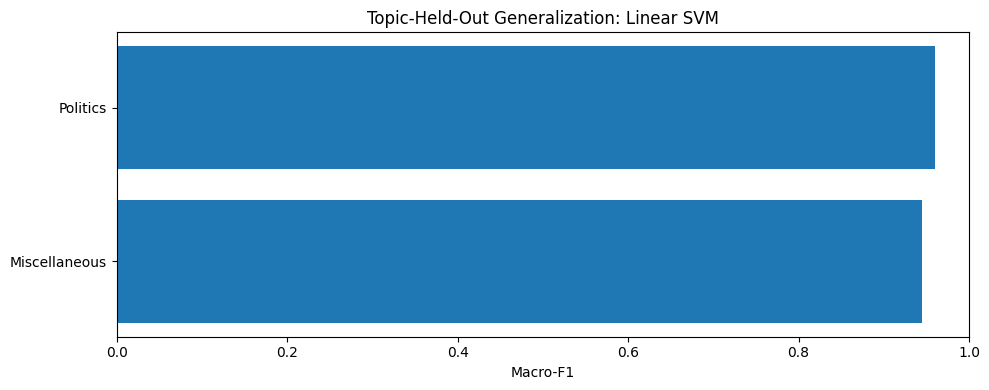

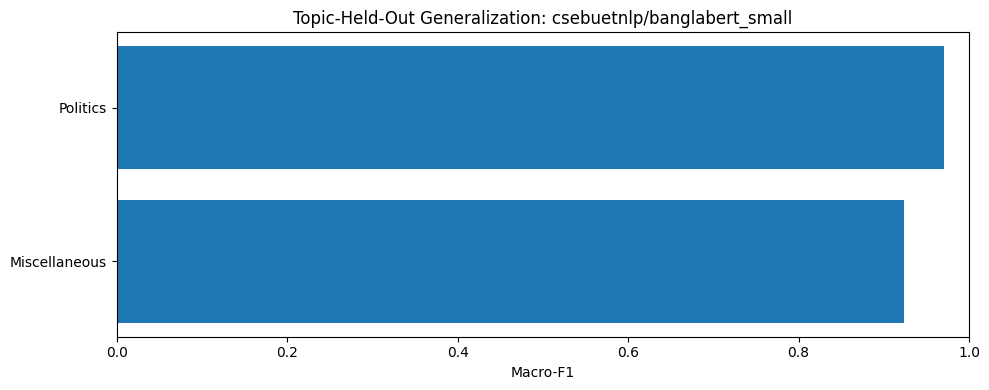

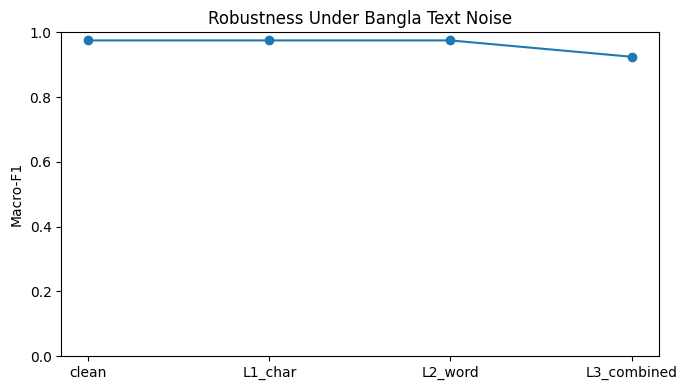

In [34]:
def plot_shift_scores(df, label_col, score_col="macro_f1", title="", filename="shift.png"):
    if df is None or len(df) == 0:
        return
    d = df[[label_col, score_col]].copy().sort_values(score_col)
    fig, ax = plt.subplots(figsize=(10, max(4, len(d)*0.45)))
    ax.barh(d[label_col].astype(str), d[score_col])
    ax.set_xlim(0, 1)
    ax.set_xlabel("Macro-F1")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / filename, dpi=250, bbox_inches="tight")
    plt.show()

if len(topic_baseline):
    plot_shift_scores(
        topic_baseline, "heldout_topic",
        title="Topic-Held-Out Generalization: Linear SVM",
        filename="fig_topic_shift_svm.png"
    )

if len(topic_transformer):
    plot_shift_scores(
        topic_transformer, "heldout_topic",
        title=f"Topic-Held-Out Generalization: {FAST_SHIFT_MODEL}",
        filename="fig_topic_shift_transformer.png"
    )

if len(robustness_results):
    fig, ax = plt.subplots(figsize=(7,4))
    ax.plot(
        robustness_results["noise_level"],
        robustness_results["macro_f1"],
        marker="o"
    )
    ax.set_ylim(0,1)
    ax.set_ylabel("Macro-F1")
    ax.set_title("Robustness Under Bangla Text Noise")
    fig.tight_layout()
    fig.savefig(
        RESULTS_DIR / "fig_noise_robustness.png",
        dpi=250, bbox_inches="tight"
    )
    plt.show()

# 22. Final paper-ready result inventory

After the run, download the entire `results/` folder.

Most important files:
- `standard_baseline_metrics.csv`
- `standard_transformer_metrics.csv`
- `topic_shift_baseline.csv`
- `topic_shift_transformer.csv`
- `source_shift_baseline.csv`
- `source_shift_transformer.csv`
- `temporal_shift_results.csv`
- `cross_dataset_results.csv`
- `robustness_results.csv`
- `generalization_gap_summary.csv`
- `high_confidence_errors.csv`
- all `fig_*.png`

## What to report in a paper
Do not select the best number from many runs and hide the others. Report:
1. ordinary in-domain performance,
2. topic/source/temporal/cross-dataset performance,
3. performance drops,
4. variance across held-out groups,
5. class-specific F1,
6. statistical paired comparison where appropriate,
7. examples from error analysis,
8. limitations and dataset/source artifacts.

In [35]:
# Zip the paper-ready outputs at the very end.
import shutil
archive = shutil.make_archive(
    "Bangla_NLP_Paper_Ready_Outputs",
    "zip",
    RESULTS_DIR
)
print("Created:", archive)

Created: /kaggle/working/Bangla_NLP_Paper_Ready_Outputs.zip
